# Análisis de absentismo y bienestar laboral - 08/06/2026

## 1. Pregunta de negocio

> ¿Cómo influyen el consumo social de alcohol o tabaco y los antecedentes disciplinarios en los niveles de absentismo?

El análisis busca detectar asociaciones, no demostrar causalidad.

## 2. Dataset limpio utilizado y alcance

Usamos el archivo limpio consolidado del `08/06/2026`. Esta parte no repite el
data cleaning; controla la muestra y las variables que entran en el análisis.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import levene, mannwhitneyu, shapiro, ttest_ind

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

# Paleta RRHH Green definida por el equipo.
COLOR_VERDE_PRINCIPAL = '#7FB8A4'
COLOR_VERDE_CLARO = '#A8D5C2'
COLOR_VERDE_OSCURO = '#5E9C87'
COLOR_VERDE_MUY_CLARO = '#CFE8DE'
COLOR_GRIS = '#D9D9D9'
COLOR_TEXTO = '#2B2B2B'
COLOR_MOSTAZARA = '#F7E9D5'
PALETA_GRUPOS = [COLOR_GRIS, COLOR_VERDE_OSCURO]

plt.rcParams.update({
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
    'axes.labelcolor': COLOR_TEXTO,
    'text.color': COLOR_TEXTO,
    'savefig.facecolor': 'none',
    'savefig.transparent': True
})

DATA_FILE = '../../Data/clean/clean_data_08062026.csv'
df_rrhh = pd.read_csv(DATA_FILE)


### 2.1 Control inicial del dataset

Se revisan tamaño, IDs y horas de absentismo para que el análisis sea trazable.

In [2]:
alcance = pd.DataFrame({
    'métrica': [
        'registros limpios',
        'IDs observados',
        'horas totales de absentismo',
        'registros con ausencia > 0 horas'
    ],
    'valor': [
        len(df_rrhh),
        df_rrhh['ID'].nunique(),
        df_rrhh['Absenteeism_hours'].sum(),
        (df_rrhh['Absenteeism_hours'] > 0).sum()
    ]
})

display(alcance)
display(df_rrhh.head())

,métrica,valor
0,registros limpios,1109
1,IDs observados,386
2,horas totales de absentismo,10155
3,registros con ausencia > 0 horas,1039


,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours,importacion
0,14,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,2,Primavera,155,12,14,34,284.031,97,0,1,Secundaria,2,1,0,0,95,196,25,24.7,120,2026-05-25
1,36,13.0,Sistema musculoesquelético,10.0,Octubre,4,Miércoles,4,Otoño,118,13,18,50,239.409,98,0,1,Secundaria,1,1,0,0,98,178,31,30.9,120,2026-05-25
2,9,6.0,Sistema nervioso,1.0,Enero,3,Martes,1,Invierno,228,14,16,58,264.604,93,0,1,Secundaria,2,0,0,1,65,172,22,22.0,120,2026-05-25
3,28,9.0,Sistema circulatorio,1.0,Enero,3,Martes,1,Invierno,225,26,9,28,230.290,92,0,1,Secundaria,1,0,0,2,69,169,24,24.2,112,2026-05-25
4,9,12.0,Piel y tejido subcutáneo,9.0,Septiembre,3,Martes,3,Verano,228,14,16,58,222.196,99,0,1,Secundaria,2,0,0,1,65,172,22,22.0,112,2026-05-25


**Lectura:** el dataset contiene `1.109` registros correspondientes a
`386` empleados. Como una misma persona puede aparecer en múltiples filas, el número
de registros no puede utilizarse como tamaño de muestra para comparar hábitos o
antecedentes. Las conclusiones se construirán sobre una fila por empleado.


------------

## 3. Variables consideradas y unidad de análisis

La lista se limita a las variables solicitadas por la pregunta de negocio:

- **Primer factor:** `Disciplinary_failure`, antecedente/falta disciplinaria.
- **Hábitos sociales:** `Social_drinker` y `Social_smoker`.
- **Variable de resultado:** horas totales de absentismo por empleado.

Los factores describen al empleado y se repiten en varias filas. Para no tratar registros del mismo ID como observaciones independientes, los contrastes se
realizan a nivel de empleado. 
`Disciplinary_failure` se agrega primero con `max()` para identificar si el ID tuvo al menos una falta disciplinaria.

In [3]:
factores = [
    'Disciplinary_failure',
    'Social_drinker',
    'Social_smoker'
]
variable_resultado = 'horas_totales_absentismo'

df_registros = df_rrhh[
    ['ID', 'Absenteeism_hours', *factores]
].copy()

df_empleados = (
    df_rrhh
    .groupby('ID', as_index=False)
    .agg(
        horas_totales_absentismo=('Absenteeism_hours', 'sum'),
        Disciplinary_failure=('Disciplinary_failure', 'max'),
        Social_drinker=('Social_drinker', 'first'),
        Social_smoker=('Social_smoker', 'first')
    )
)

df_empleados[factores + [variable_resultado]].describe().T

,count,mean,std,min,25%,50%,75%,max
Disciplinary_failure,386.0,0.116580,0.321336,0.0,0.0,0.0,0.0,1.0
Social_drinker,386.0,0.564767,0.496431,0.0,0.0,1.0,1.0,1.0
Social_smoker,386.0,0.119171,0.324410,0.0,0.0,0.0,0.0,1.0
horas_totales_absentismo,386.0,26.308290,90.877887,0.0,2.0,4.0,8.0,844.0


**Lectura:** la agregación por `ID` convierte las horas registradas en horas totales por empleado y conserva cada factor como una característica binaria.
Esta decisión evita que los empleados con más registros tengan más peso estadístico solo por aparecer más veces.

### 3.1 Composición de los grupos dentro del absentismo

La elipse exterior representa a los empleados que presentan absentismo. Dentro se muestran los tres grupos incluidos en la pregunta y sus solapamientos.

La zona exterior al Venn identifica a los empleados con absentismo que no son fumadores sociales, no son bebedores sociales y no tienen antecedentes disciplinarios.

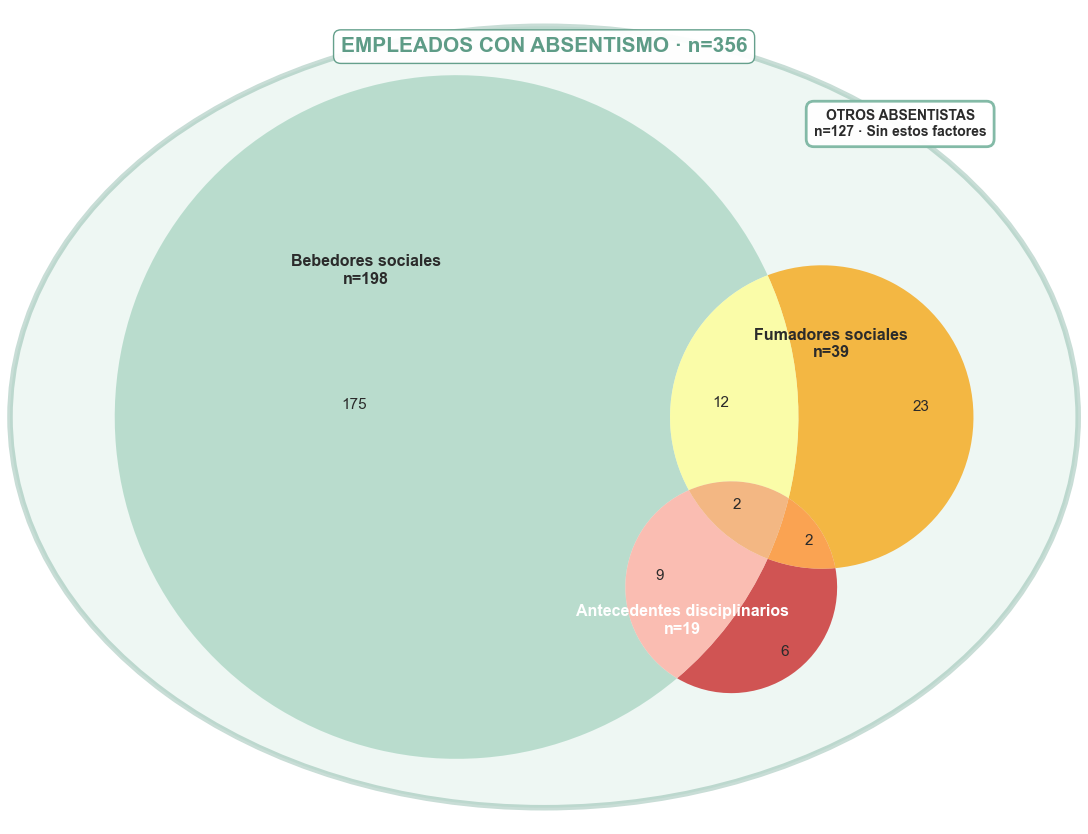

,grupo,empleados
0,Empleados con absentismo,356
1,Dentro de al menos uno de los tres factores,229
2,Otros perfiles con absentismo,127


In [4]:
from matplotlib.patches import Ellipse
from matplotlib_venn import venn3

# Una fila por empleado: hábitos mediante first(), antecedentes mediante max().
grupos_venn = (
    df_rrhh
    .groupby('ID', as_index=False)
    .agg(
        horas_totales_absentismo=('Absenteeism_hours', 'sum'),
        Social_drinker=('Social_drinker', 'first'),
        Social_smoker=('Social_smoker', 'first'),
        Disciplinary_failure=('Disciplinary_failure', 'max')
    )
)

ids_con_absentismo = set(
    grupos_venn.loc[grupos_venn['horas_totales_absentismo'] > 0, 'ID']
)
set_bebedores = set(
    grupos_venn.loc[
        (grupos_venn['Social_drinker'] == 1)
        & (grupos_venn['horas_totales_absentismo'] > 0),
        'ID'
    ]
)
set_fumadores = set(
    grupos_venn.loc[
        (grupos_venn['Social_smoker'] == 1)
        & (grupos_venn['horas_totales_absentismo'] > 0),
        'ID'
    ]
)
set_antecedentes = set(
    grupos_venn.loc[
        (grupos_venn['Disciplinary_failure'] == 1)
        & (grupos_venn['horas_totales_absentismo'] > 0),
        'ID'
    ]
)

union_factores = set_bebedores | set_fumadores | set_antecedentes
otros_con_absentismo = ids_con_absentismo - union_factores

fig, ax = plt.subplots(figsize=(12, 8.5))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
ax.axis('off')

# El Venn se genera sin etiquetas externas; los nombres se colocan dentro.
venn = venn3(
    [set_bebedores, set_fumadores, set_antecedentes],
    set_labels=('', '', ''),
    set_colors=(
        COLOR_VERDE_CLARO,
        '#F5A20A',  # Mostaza: fumadores sociales
        '#C71F1F'   # Rojo: antecedentes disciplinarios
    ),
    alpha=0.75,
    ax=ax
)

# Elipse exterior: universo completo de empleados con absentismo.
elipse_absentismo = Ellipse(
    (0.5, 0.5),
    width=1.08,
    height=0.96,
    transform=ax.transAxes,
    facecolor=COLOR_VERDE_MUY_CLARO,
    edgecolor=COLOR_VERDE_OSCURO,
    linewidth=4,
    alpha=0.34,
    zorder=-10,
    clip_on=False
)
ax.add_patch(elipse_absentismo)

for label in venn.subset_labels:
    if label is not None:
        label.set_fontsize(11)
        label.set_color(COLOR_TEXTO)

# Título del conjunto exterior, claramente separado de los conjuntos internos.
ax.text(
    0.5,
    0.955,
    f'EMPLEADOS CON ABSENTISMO · n={len(ids_con_absentismo)}',
    transform=ax.transAxes,
    fontsize=15,
    fontweight='bold',
    color=COLOR_VERDE_OSCURO,
    ha='center',
    va='center',
    bbox={
        'boxstyle': 'round,pad=0.35',
        'facecolor': 'white',
        'edgecolor': COLOR_VERDE_OSCURO,
        'alpha': 0.95
    }
)

# Etiquetas dentro de cada conjunto.
ax.text(
    0.32,
    0.68,
    f'Bebedores sociales\nn={len(set_bebedores)}',
    transform=ax.transAxes,
    ha='center',
    va='center',
    fontsize=11.5,
    fontweight='bold',
    color=COLOR_TEXTO
)
ax.text(
    0.79,
    0.59,
    f'Fumadores sociales\nn={len(set_fumadores)}',
    transform=ax.transAxes,
    ha='center',
    va='center',
    fontsize=11.5,
    fontweight='bold',
    color=COLOR_TEXTO
)
ax.text(
    0.64,
    0.25,
    f'Antecedentes disciplinarios\nn={len(set_antecedentes)}',
    transform=ax.transAxes,
    ha='center',
    va='center',
    fontsize=11.5,
    fontweight='bold',
    color='white'
)

# La caja de otros perfiles se sitúa en la zona superior derecha libre.
ax.text(
    0.86,
    0.86,
    f'OTROS ABSENTISTAS\nn={len(otros_con_absentismo)} · Sin estos factores',
    transform=ax.transAxes,
    fontsize=10,
    fontweight='bold',
    color=COLOR_TEXTO,
    ha='center',
    va='center',
    bbox={
        'boxstyle': 'round,pad=0.55',
        'facecolor': 'white',
        'edgecolor': COLOR_VERDE_PRINCIPAL,
        'linewidth': 2,
        'alpha': 0.96
    }
)

ax.set_title(
    '',
    fontsize=20,
    fontweight='bold',
    color=COLOR_TEXTO,
    pad=22
)
plt.tight_layout()
plt.savefig(
    'grafica0_venn_grupos.png',
    dpi=150,
    bbox_inches='tight',
    transparent=True
)
plt.show()

pd.DataFrame({
    'grupo': [
        'Empleados con absentismo',
        'Dentro de al menos uno de los tres factores',
        'Otros perfiles con absentismo'
    ],
    'empleados': [
        len(ids_con_absentismo),
        len(union_factores),
        len(otros_con_absentismo)
    ]
})

Los tres factores de estudio **no** describen el 100% del absentismo. <br>
De los `356` empleados con horas de ausencia, `229` pertenecen al menos a uno de los tres grupos y `127` quedan fuera de ellos. <br>
Esta zona de “otros perfiles” muestra que también existe absentismo sin consumo social de alcohol o tabaco y sin antecedentes disciplinarios.

## 4. Validación previa de `Disciplinary_failure`

Antes de correr ningún test se comprueba la variable disciplinaria en las dos unidades posibles. <br>
A nivel de registro, todas las filas con falta disciplinaria tienen cero horas. <br>
A nivel de empleado, `max()` identifica si el ID tuvo al menos una falta y las horas se acumulan sin perder sus otros registros.


In [5]:
validacion_disciplinaria_registros = (
    df_registros
    .groupby('Disciplinary_failure')
    .agg(
        registros=('ID', 'size'),
        empleados=('ID', 'nunique'),
        registros_con_ausencia=(
            'Absenteeism_hours',
            lambda serie: (serie > 0).sum()
        ),
        horas_totales=('Absenteeism_hours', 'sum'),
        media_horas=('Absenteeism_hours', 'mean'),
        mediana_horas=('Absenteeism_hours', 'median'),
        valores_unicos_horas=('Absenteeism_hours', 'nunique')
    )
)

validacion_disciplinaria_empleados = (
    df_empleados
    .groupby('Disciplinary_failure')
    .agg(
        empleados=('ID', 'size'),
        horas_totales=(variable_resultado, 'sum'),
        media_horas=(variable_resultado, 'mean'),
        mediana_horas=(variable_resultado, 'median'),
        valores_unicos_horas=(variable_resultado, 'nunique')
    )
)

display(validacion_disciplinaria_registros)
display(validacion_disciplinaria_empleados)

,registros,empleados,registros_con_ausencia,horas_totales,media_horas,mediana_horas,valores_unicos_horas
Disciplinary_failure,,,,,,,
0,1045,361,1039,10155,9.717703,3.0,19
1,64,45,0,0,0.000000,0.0,1


,empleados,horas_totales,media_horas,mediana_horas,valores_unicos_horas
Disciplinary_failure,,,,,
0,341,6205,18.196481,4.0,31
1,45,3950,87.777778,0.0,19


**Lectura previa al test:** el contraste por filas no es adecuado porque repite empleados y `Disciplinary_failure = 1` aparece estructuralmente asociado a filas de cero horas. Por eso el test se ejecuta a nivel de `ID`: cada empleado aparece una vez, se conserva si tuvo una falta y se comparan sus horas totales de absentismo.

## 5. Estadísticos descriptivos por empleado

Primero se observan tamaño, media, mediana y variabilidad de los grupos `0/1`.
La elección del test se realiza después de esta revisión.

In [6]:
resumen_descriptivo = (
    df_empleados
    .melt(
        id_vars=['ID', variable_resultado],
        value_vars=factores,
        var_name='factor',
        value_name='grupo'
    )
    .groupby(['factor', 'grupo'])
    .agg(
        empleados=('ID', 'size'),
        horas_totales=(variable_resultado, 'sum'),
        media_horas=(variable_resultado, 'mean'),
        mediana_horas=(variable_resultado, 'median'),
        valores_unicos=(variable_resultado, 'nunique')
    )
    .round(2)
)

resumen_descriptivo

empleados  horas_totales  media_horas  \
factor               grupo                                          
Disciplinary_failure 0            341           6205        18.20   
                     1             45           3950        87.78   
Social_drinker       0            168           4203        25.02   
                     1            218           5952        27.30   
Social_smoker        0            340           9539        28.06   
                     1             46            616        13.39   

                            mediana_horas  valores_unicos  
factor               grupo                                 
Disciplinary_failure 0                4.0              31  
                     1                0.0              19  
Social_drinker       0                3.0              26  
                     1                4.0              31  
Social_smoker        0                4.0              41  
                     1                5.5              12

**Lectura descriptiva:**

- `Disciplinary_failure` presenta el patrón más diferente, aunque incluye muchos
  empleados con cero horas y no permite conocer si la falta ocurrió antes o después
  de las ausencias.
- `Social_drinker` y `Social_smoker` muestran distribuciones ampliamente
  solapadas respecto a sus grupos de comparación.
- Las distribuciones son muy asimétricas y contienen valores extremos.

Por ello, la interpretación no debe basarse únicamente en medias o medianas.


## 6. Selección y aplicación del test

Para cada factor binario se comprueba que existan dos grupos, variabilidad y normalidad aproximada.<br> 
Si algún grupo es pequeño, constante o no normal, se aplica `Mann-Whitney U`. <br>
Solo si ambos grupos son aproximadamente normales se evalúan varianzas para elegir entre `t-test de Student` y `Welch t-test`.
La unidad de análisis es el empleado, por lo que cada ID interviene una sola vez.

In [7]:
def seleccionar_test_binario(
    dataframe,
    factor,
    target='Absenteeism_hours',
    alpha=0.05
):
    """
    Selecciona y aplica el test adecuado para comparar dos grupos.
    """
    datos = dataframe[[factor, target]].dropna()
    grupos = sorted(datos[factor].unique())

    if len(grupos) != 2:
        return {
            'factor': factor,
            'test_usado': 'No aplicable',
            'p_value': np.nan,
            'motivo': 'La variable no tiene exactamente dos grupos.'
        }

    grupo_0 = datos.loc[datos[factor] == grupos[0], target]
    grupo_1 = datos.loc[datos[factor] == grupos[1], target]
    n_0, n_1 = len(grupo_0), len(grupo_1)
    constante_0 = grupo_0.nunique() <= 1
    constante_1 = grupo_1.nunique() <= 1
    shapiro_p_0 = np.nan
    shapiro_p_1 = np.nan
    levene_p = np.nan

    if constante_0 and constante_1:
        test_usado = 'No aplicable'
        estadistico = np.nan
        p_value = np.nan
        motivo = 'Ambos grupos son constantes.'
    elif constante_0 or constante_1 or n_0 < 30 or n_1 < 30:
        test_usado = 'Mann-Whitney U'
        estadistico, p_value = mannwhitneyu(
            grupo_0,
            grupo_1,
            alternative='two-sided'
        )
        motivo = 'Hay un grupo constante o con menos de 30 observaciones.'
    else:
        shapiro_p_0 = shapiro(grupo_0).pvalue
        shapiro_p_1 = shapiro(grupo_1).pvalue
        grupos_normales = shapiro_p_0 >= alpha and shapiro_p_1 >= alpha

        if not grupos_normales:
            test_usado = 'Mann-Whitney U'
            estadistico, p_value = mannwhitneyu(
                grupo_0,
                grupo_1,
                alternative='two-sided'
            )
            motivo = 'No se cumple normalidad aproximada.'
        else:
            levene_p = levene(grupo_0, grupo_1).pvalue
            varianzas_iguales = levene_p >= alpha
            test_usado = (
                't-test de Student'
                if varianzas_iguales
                else 'Welch t-test'
            )
            estadistico, p_value = ttest_ind(
                grupo_0,
                grupo_1,
                equal_var=varianzas_iguales
            )
            motivo = (
                'Normalidad aproximada y varianzas similares.'
                if varianzas_iguales
                else 'Normalidad aproximada y varianzas diferentes.'
            )

    return {
        'factor': factor,
        'n_grupo_0': n_0,
        'n_grupo_1': n_1,
        'media_grupo_0': grupo_0.mean(),
        'media_grupo_1': grupo_1.mean(),
        'mediana_grupo_0': grupo_0.median(),
        'mediana_grupo_1': grupo_1.median(),
        'shapiro_p_grupo_0': shapiro_p_0,
        'shapiro_p_grupo_1': shapiro_p_1,
        'levene_p': levene_p,
        'test_usado': test_usado,
        'estadistico': estadistico,
        'p_value': p_value,
        'significativo_005': p_value < alpha if pd.notna(p_value) else False,
        'motivo': motivo
    }


resultados_tests = pd.DataFrame([
    seleccionar_test_binario(df_empleados, factor, variable_resultado)
    for factor in factores
])

resultados_tests

,factor,n_grupo_0,n_grupo_1,media_grupo_0,media_grupo_1,mediana_grupo_0,mediana_grupo_1,shapiro_p_grupo_0,shapiro_p_grupo_1,levene_p,test_usado,estadistico,p_value,significativo_005,motivo
0,Disciplinary_failure,341,45,18.196481,87.777778,4.0,0.0,2.301243e-35,4.188710e-10,NaN,Mann-Whitney U,9248.5,0.023433,True,No se cumple normalidad aproximada.
1,Social_drinker,168,218,25.017857,27.302752,3.0,4.0,3.668239e-25,2.791748e-28,NaN,Mann-Whitney U,17601.5,0.508557,False,No se cumple normalidad aproximada.
2,Social_smoker,340,46,28.055882,13.391304,4.0,5.5,4.793935e-34,8.635812e-12,NaN,Mann-Whitney U,7901.0,0.908683,False,No se cumple normalidad aproximada.


In [8]:
# Tamaño del efecto basado en rangos: diferencia en la probabilidad
# de que un empleado del grupo 1 presente más horas que uno del grupo 0.
def efecto_rank_biserial(dataframe, factor, target):
    """
    Calcula el tamaño del efecto rank-biserial entre dos grupos.
    """
    grupo_0 = dataframe.loc[dataframe[factor] == 0, target].dropna()
    grupo_1 = dataframe.loc[dataframe[factor] == 1, target].dropna()
    u_grupo_0, _ = mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')
    return 1 - (2 * u_grupo_0) / (len(grupo_0) * len(grupo_1))


resultados_tests['efecto_rank_biserial'] = [
    efecto_rank_biserial(df_empleados, factor, variable_resultado)
    for factor in resultados_tests['factor']
]

resultados_tests[['factor', 'test_usado', 'p_value', 'efecto_rank_biserial']]

,factor,test_usado,p_value,efecto_rank_biserial
0,Disciplinary_failure,Mann-Whitney U,0.023433,-0.205409
1,Social_drinker,Mann-Whitney U,0.508557,0.038800
2,Social_smoker,Mann-Whitney U,0.908683,-0.010358


**Lectura del test:** se utiliza `Mann-Whitney U` en los tres factores porque las distribuciones no son normales o uno de los grupos es pequeño. <br> 
El p-valor indica si existe evidencia de diferencias, mientras que el tamaño del efecto ayuda a valorar su intensidad y dirección.

- Un efecto cercano a `0` indica distribuciones similares.
- Un efecto positivo indica que el grupo `1` tiende a presentar más horas.
- El resultado debe interpretarse junto con el tamaño de cada grupo y el contexto de la variable.

## 7. Visualización comparativa

Se priorizan mediana y dispersión porque las distribuciones por empleado no son normales.

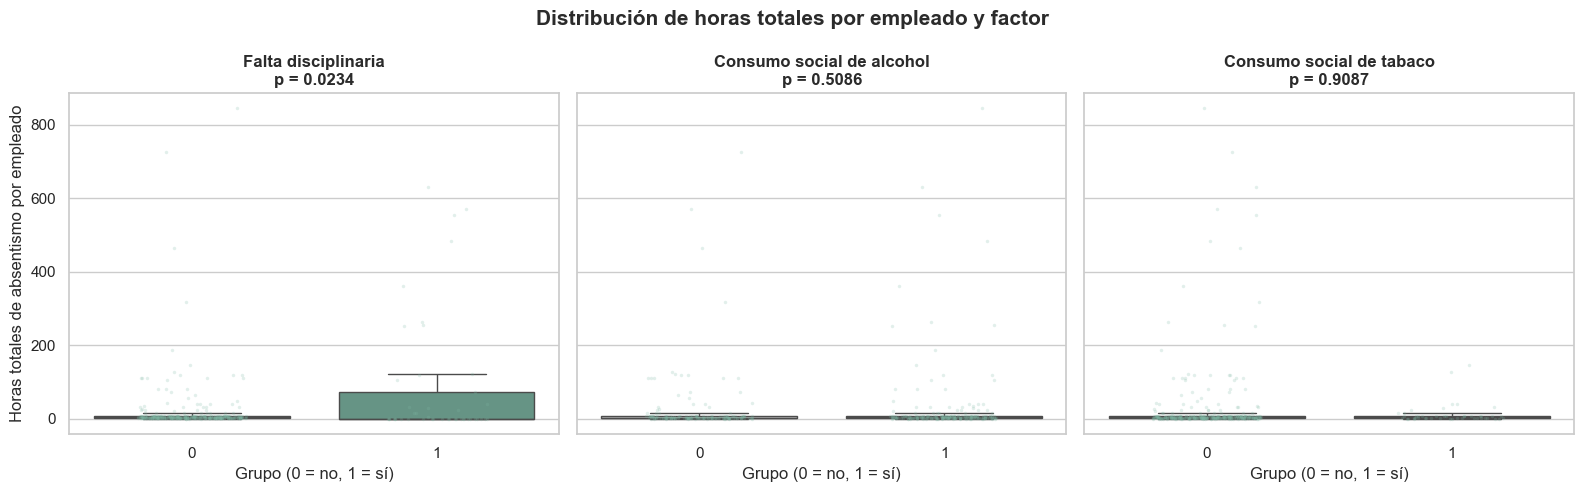

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
nombres = {
    'Disciplinary_failure': 'Falta disciplinaria',
    'Social_drinker': 'Consumo social de alcohol',
    'Social_smoker': 'Consumo social de tabaco'
}

for axis, factor in zip(axes, factores):
    sns.boxplot(
        data=df_empleados,
        x=factor,
        y=variable_resultado,
        hue=factor,
        palette=PALETA_GRUPOS,
        legend=False,
        showfliers=False,
        ax=axis
    )
    sns.stripplot(
        data=df_empleados,
        x=factor,
        y=variable_resultado,
        color=COLOR_VERDE_PRINCIPAL,
        alpha=0.22,
        size=2.5,
        jitter=0.22,
        ax=axis
    )
    p_value = resultados_tests.loc[
        resultados_tests['factor'] == factor,
        'p_value'
    ].iloc[0]
    etiqueta_p = 'p < 0.001' if p_value < 0.001 else f'p = {p_value:.4f}'
    axis.set_title(f"{nombres[factor]}\n{etiqueta_p}", fontweight='bold')
    axis.set_xlabel('Grupo (0 = no, 1 = sí)')
    axis.set_ylabel('Horas totales de absentismo por empleado')

fig.suptitle(
    'Distribución de horas totales por empleado y factor',
    fontsize=15,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('grafica1_boxplot_factores.png', dpi=150, bbox_inches='tight')
plt.show()

**Lectura del boxplot:** los tres factores presentan gran dispersión y solapamiento entre grupos. Los antecedentes disciplinarios muestran un patrón particular por la presencia simultánea de empleados con cero horas y empleados con absentismo muy alto. Alcohol y tabaco no muestran una separación visual clara.

El boxplot es útil para mostrar mediana y dispersión, pero los valores extremos comprimen visualmente los grupos. Por eso se añade una curva acumulada para comparar toda la distribución.

## 8. Resultados de los contrastes

La tabla resume el test elegido después de validar los supuestos. El p-valor se interpreta junto con medias, medianas y tamaños de grupo.

In [10]:
resumen_tests = resultados_tests[[
    'factor',
    'n_grupo_0',
    'n_grupo_1',
    'media_grupo_0',
    'media_grupo_1',
    'mediana_grupo_0',
    'mediana_grupo_1',
    'test_usado',
    'p_value',
    'significativo_005',
    'motivo'
]].copy()

columnas_redondear = [
    'media_grupo_0',
    'media_grupo_1',
    'mediana_grupo_0',
    'mediana_grupo_1',
    'p_value'
]
resumen_tests[columnas_redondear] = resumen_tests[
    columnas_redondear
].round(4)

resumen_tests

,factor,n_grupo_0,n_grupo_1,media_grupo_0,media_grupo_1,mediana_grupo_0,mediana_grupo_1,test_usado,p_value,significativo_005,motivo
0,Disciplinary_failure,341,45,18.1965,87.7778,4.0,0.0,Mann-Whitney U,0.0234,True,No se cumple normalidad aproximada.
1,Social_drinker,168,218,25.0179,27.3028,3.0,4.0,Mann-Whitney U,0.5086,False,No se cumple normalidad aproximada.
2,Social_smoker,340,46,28.0559,13.3913,4.0,5.5,Mann-Whitney U,0.9087,False,No se cumple normalidad aproximada.


### 8.1 Resumen visual para la presentación

Este gráfico resume la mediana de cada grupo, el tamaño muestral y la significación.
Es más directo para una diapositiva, mientras que el boxplot y la ECDF conservan el detalle estadístico en el notebook.

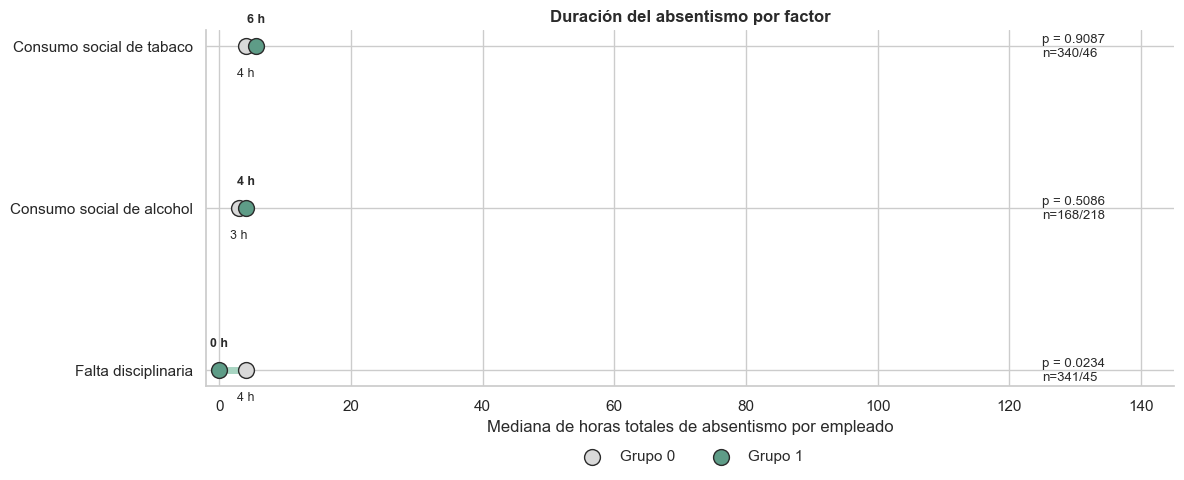

In [11]:
resumen_visual = resultados_tests.copy()
resumen_visual['factor_nombre'] = resumen_visual['factor'].map(nombres)

fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
posiciones = np.arange(len(resumen_visual))

for posicion, fila in resumen_visual.iterrows():
    mediana_0 = fila['mediana_grupo_0']
    mediana_1 = fila['mediana_grupo_1']
    ax.plot(
        [mediana_0, mediana_1],
        [posicion, posicion],
        color=COLOR_VERDE_CLARO,
        linewidth=5,
        solid_capstyle='round'
    )
    ax.scatter(
        mediana_0,
        posicion,
        s=130,
        color=COLOR_GRIS,
        edgecolor=COLOR_TEXTO,
        label='Grupo 0' if posicion == 0 else None,
        zorder=3
    )
    ax.scatter(
        mediana_1,
        posicion,
        s=130,
        color=COLOR_VERDE_OSCURO,
        edgecolor=COLOR_TEXTO,
        label='Grupo 1' if posicion == 0 else None,
        zorder=3
    )
    ax.text(
        mediana_0,
        posicion - 0.13,
        f'{mediana_0:.0f} h',
        ha='center',
        va='top',
        fontsize=9
    )
    ax.text(
        mediana_1,
        posicion + 0.13,
        f'{mediana_1:.0f} h',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )
    p_texto = 'p < 0.001' if fila['p_value'] < 0.001 else f"p = {fila['p_value']:.4f}"
    ax.text(
        125,
        posicion,
        f"{p_texto}\nn={int(fila['n_grupo_0'])}/{int(fila['n_grupo_1'])}",
        va='center',
        fontsize=9.5
    )

ax.set_xlim(-2, 145)
ax.set_yticks(posiciones)
ax.set_yticklabels(resumen_visual['factor_nombre'])
ax.set_xlabel('Mediana de horas totales de absentismo por empleado')
ax.set_title('Duración del absentismo por factor', fontweight='bold')
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.14),
    ncol=2
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

**Lectura ejecutiva:** el gráfico permite separar tres mensajes:

1. **Alcohol:** no existe evidencia estadística de diferencias.
2. **Tabaco:** con la muestra ampliada tampoco existe evidencia estadística de
   diferencias.
3. **Antecedentes disciplinarios:** mantienen una asociación estadística, aunque
   el patrón mezcla empleados sin ausencia con una fuerte concentración en el
   nivel alto y requiere interpretar la variable con RRHH.


### 8.2 Correlación de los factores con las horas de absentismo

Como primera lectura de relación se calcula la correlación de Spearman entre cada factor y las horas totales de absentismo por empleado. Se utiliza Spearman porque las horas presentan una distribución asimétrica y los factores son binarios.

La visualización se limita a las correlaciones contra la variable resultado. Las relaciones entre alcohol, tabaco y antecedentes disciplinarios no responden directamente a la pregunta de negocio y añadirían ruido a la lectura.


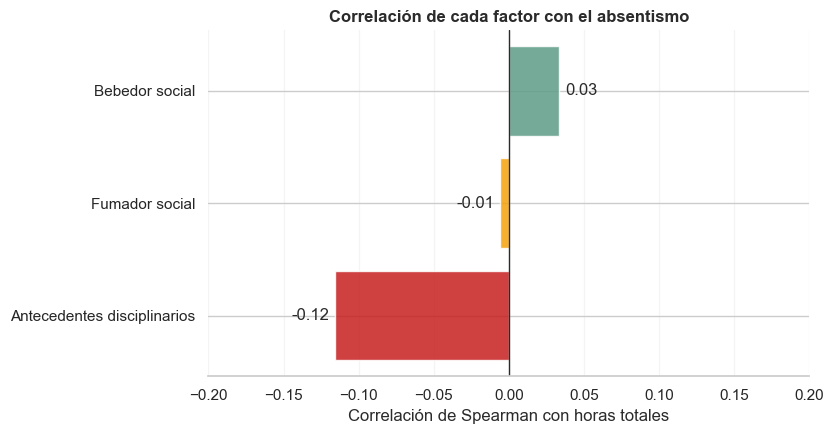

,correlacion_spearman
Antecedentes disciplinarios,-0.115538
Fumador social,-0.005882
Bebedor social,0.033716


In [12]:
correlacion_absentismo = (
    df_empleados[
        [
            'Social_drinker',
            'Social_smoker',
            'Disciplinary_failure',
            variable_resultado
        ]
    ]
    .corr(method='spearman')[variable_resultado]
    .drop(variable_resultado)
    .rename(index={
        'Social_drinker': 'Bebedor social',
        'Social_smoker': 'Fumador social',
        'Disciplinary_failure': 'Antecedentes disciplinarios'
    })
    .sort_values()
)

colores_correlacion = [
    '#C71F1F' if etiqueta == 'Antecedentes disciplinarios'
    else '#F5A20A' if etiqueta == 'Fumador social'
    else COLOR_VERDE_OSCURO
    for etiqueta in correlacion_absentismo.index
]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
fig.patch.set_alpha(0)
ax.set_facecolor('none')

barras = ax.barh(
    correlacion_absentismo.index,
    correlacion_absentismo.values,
    color=colores_correlacion,
    alpha=0.85
)

ax.axvline(0, color=COLOR_TEXTO, linewidth=1)
ax.bar_label(barras, fmt='%.2f', padding=4)
ax.set_xlim(-0.2, 0.2)
ax.set_xlabel('Correlación de Spearman con horas totales')
ax.set_title(
    'Correlación de cada factor con el absentismo',
    fontweight='bold'
)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.savefig(
    'grafica_correlacion_factores_absentismo.png',
    dpi=150,
    bbox_inches='tight',
    transparent=True
)
plt.show()

correlacion_absentismo.to_frame('correlacion_spearman')


**Lectura de la correlación:** los tres coeficientes son débiles. Alcohol y tabaco presentan una relación prácticamente nula con las horas totales. Los antecedentes disciplinarios muestran una correlación negativa débil, influida por la presencia de empleados con antecedentes y cero horas.

Esta lectura inicial no sustituye los contrastes posteriores. Al estudiar los antecedentes por niveles y mediante regresión aparece su concentración específica en el absentismo alto, un patrón que una correlación única no consigue representar.


## 9. Análisis complementario: tres niveles de absentismo

Para observar dónde se concentra el impacto, los `356` empleados con horas de ausencia se distribuyen en tres niveles operativos:

- **Bajo:** entre `1` y `3` horas.
- **Medio:** entre `4` y `8` horas.
- **Alto:** más de `8` horas.

Los grupos contienen `162`, `128` y `66` empleados. Los límites mantienen juntos a los empleados que tienen exactamente las mismas horas y permiten comparar niveles con suficiente muestra.

In [13]:
from scipy.stats import chi2_contingency, fisher_exact

df_niveles = df_empleados[df_empleados[variable_resultado] > 0].copy()
orden_niveles = [
    'Bajo (1-3 h)',
    'Medio (4-8 h)',
    'Alto (>8 h)'
]

df_niveles['nivel_absentismo'] = pd.cut(
    df_niveles[variable_resultado],
    bins=[0, 3, 8, np.inf],
    labels=orden_niveles,
    include_lowest=True
)

resumen_niveles = (
    df_niveles
    .groupby('nivel_absentismo', observed=False)
    .agg(
        empleados=('ID', 'size'),
        horas_totales=(variable_resultado, 'sum'),
        mediana_horas=(variable_resultado, 'median'),
        pct_bebedores=('Social_drinker', 'mean'),
        pct_fumadores=('Social_smoker', 'mean'),
        pct_antecedentes=('Disciplinary_failure', 'mean')
    )
)

resumen_niveles['pct_horas_totales'] = (
    resumen_niveles['horas_totales']
    / resumen_niveles['horas_totales'].sum()
    * 100
)

columnas_porcentaje = [
    'pct_bebedores',
    'pct_fumadores',
    'pct_antecedentes',
    'pct_horas_totales'
]
resumen_niveles[columnas_porcentaje] = (
    resumen_niveles[columnas_porcentaje] * [100, 100, 100, 1]
).round(1)

resumen_niveles

,empleados,horas_totales,mediana_horas,pct_bebedores,pct_fumadores,pct_antecedentes,pct_horas_totales
nivel_absentismo,,,,,,,
Bajo (1-3 h),162,335,2.0,50.0,9.9,0.0,3.3
Medio (4-8 h),128,894,8.0,61.7,10.9,0.8,8.8
Alto (>8 h),66,8926,60.0,57.6,13.6,27.3,87.9


### 9.1 Peso de los niveles sobre las horas totales

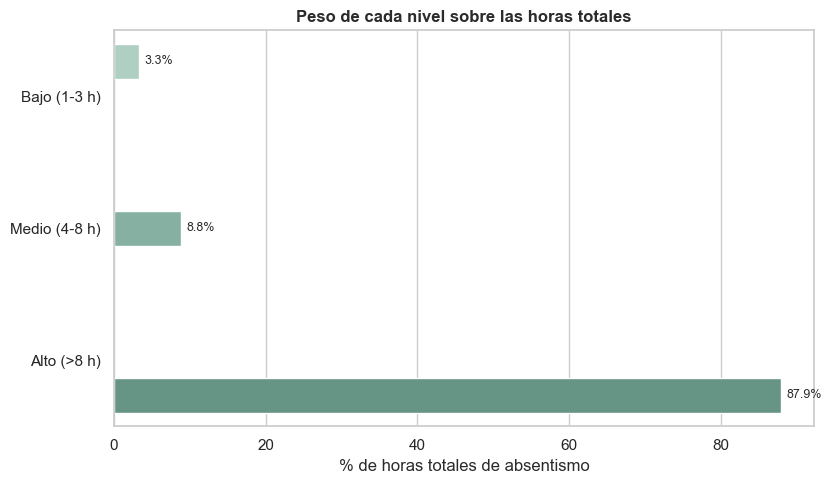

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 5))
fig.patch.set_alpha(0)
ax.set_facecolor('none')

datos_peso = resumen_niveles.reset_index()
sns.barplot(
    data=datos_peso,
    y='nivel_absentismo',
    x='pct_horas_totales',
    hue='nivel_absentismo',
    palette=[COLOR_VERDE_CLARO, COLOR_VERDE_PRINCIPAL, COLOR_VERDE_OSCURO],
    legend=False,
    ax=ax
)
ax.set_title('Peso de cada nivel sobre las horas totales', fontweight='bold')
ax.set_xlabel('% de horas totales de absentismo')
ax.set_ylabel('')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=4, fontsize=9)

plt.tight_layout()
plt.savefig('grafica4_peso_niveles.png', dpi=150, bbox_inches='tight')
plt.show()

**Sobre Kruskal-Wallis:** no se aplica Kruskal-Wallis para comparar las horas de absentismo entre los niveles bajo, medio y alto. Estos grupos fueron construidos utilizando directamente las horas (`1-3`, `4-8` y `>8`), por lo que encontrar diferencias entre ellos está garantizado por definición y el resultado del test sería circular.

Para comprobar si los factores estudiados se distribuyen de forma diferente entre los tres niveles se utiliza Chi-cuadrado. Posteriormente, la regresión multinomial permite analizar conjuntamente la probabilidad de pertenecer a cada nivel.


### 9.2 Presencia de factores dentro de cada nivel

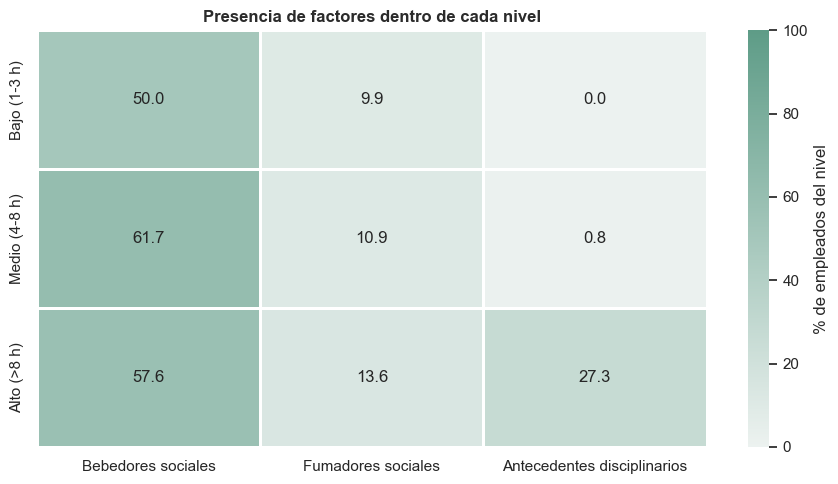

In [15]:
matriz_factores = resumen_niveles[[
    'pct_bebedores',
    'pct_fumadores',
    'pct_antecedentes'
]].rename(columns={
    'pct_bebedores': 'Bebedores sociales',
    'pct_fumadores': 'Fumadores sociales',
    'pct_antecedentes': 'Antecedentes disciplinarios'
})

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_alpha(0)
ax.set_facecolor('none')
sns.heatmap(
    matriz_factores,
    annot=True,
    fmt='.1f',
    cmap=sns.light_palette(COLOR_VERDE_OSCURO, as_cmap=True),
    vmin=0,
    vmax=100,
    linewidths=0.8,
    cbar_kws={'label': '% de empleados del nivel'},
    ax=ax
)
ax.set_title('Presencia de factores dentro de cada nivel', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('grafica5_factores_niveles.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Asociación entre factores y los tres niveles: Chi-cuadrado

Después de crear los tres niveles, Chi-cuadrado permite comprobar si la distribución de empleados entre nivel bajo, medio y alto depende de cada factor.
El resultado solo se considera válido cuando las frecuencias esperadas son suficientes.

In [16]:
resultados_chi_niveles = []

for factor in factores:
    tabla = pd.crosstab(df_niveles[factor], df_niveles['nivel_absentismo'])
    chi2, p_value, grados_libertad, esperadas = chi2_contingency(tabla)
    pct_celdas_menor_5 = (esperadas < 5).mean() * 100
    supuestos_validos = esperadas.min() >= 1 and pct_celdas_menor_5 <= 20

    resultados_chi_niveles.append({
        'factor': factor,
        'chi2': chi2,
        'p_value': p_value,
        'frecuencia_esperada_minima': esperadas.min(),
        'pct_celdas_esperadas_menor_5': pct_celdas_menor_5,
        'supuestos_chi_cuadrado_validos': supuestos_validos,
        'significativo_si_valido': p_value < 0.05 if supuestos_validos else np.nan
    })

resultados_chi_niveles_df = pd.DataFrame(resultados_chi_niveles)
resultados_chi_niveles_df

,factor,chi2,p_value,frecuencia_esperada_minima,pct_celdas_esperadas_menor_5,supuestos_chi_cuadrado_validos,significativo_si_valido
0,Disciplinary_failure,77.250144,1.680136e-17,3.522472,16.666667,True,True
1,Social_drinker,4.103829,1.284887e-01,29.292135,0.000000,True,False
2,Social_smoker,0.679634,7.119008e-01,7.230337,0.000000,True,False


**Lectura Chi-cuadrado de los tres niveles:** ni alcohol ni tabaco presentan asociación estadísticamente significativa con los niveles de absentismo. <br>
Los antecedentes disciplinarios sí presentan una asociación clara y cumplen el criterio establecido para utilizar Chi-cuadrado, aunque una frecuencia esperada es inferior a `5`.

**Lectura:** el nivel alto contiene `66` empleados y concentra aproximadamente el `87,9%` de las horas totales. Los antecedentes disciplinarios aparecen especialmente concentrados en este nivel.<br>
Alcohol y tabaco presentan porcentajes relativamente similares entre niveles.

Los porcentajes de los factores no deben sumarse: un empleado puede pertenecer a varios grupos simultáneamente.

### 9.4 Probabilidad de pertenecer al nivel elevado

Para complementar Mann-Whitney U, se categoriza el resultado utilizando el percentil 75 de horas totales por empleado:

- `0`: hasta el percentil 75.
- `1`: por encima del percentil 75.

El umbral se calcula directamente con los datos actuales. Se utiliza Chi-cuadrado cuando las frecuencias esperadas son suficientes y Fisher exact cuando alguna frecuencia esperada es inferior a `5`.

In [17]:
df_elevado = df_empleados.copy()
umbral_absentismo_elevado = df_elevado[variable_resultado].quantile(0.75)
df_elevado['absentismo_elevado'] = (
    df_elevado[variable_resultado] > umbral_absentismo_elevado
)

print('Umbral de absentismo elevado:', umbral_absentismo_elevado, 'horas')

resultados_elevado = []
for factor in factores:
    tabla = pd.crosstab(
        df_elevado[factor],
        df_elevado['absentismo_elevado']
    )
    chi2, p_chi, _, esperadas = chi2_contingency(tabla)
    odds_ratio, p_fisher = fisher_exact(tabla)

    if esperadas.min() < 5:
        test = 'Fisher exact'
        p_value = p_fisher
    else:
        test = 'Chi-cuadrado'
        p_value = p_chi

    resultados_elevado.append({
        'factor': factor,
        'test_seleccionado': test,
        'p_value': p_value,
        'odds_ratio': odds_ratio,
        'frecuencia_esperada_minima': esperadas.min(),
        'significativo_005': p_value < 0.05
    })

resultados_elevado_df = pd.DataFrame(resultados_elevado)
resultados_elevado_df


Umbral de absentismo elevado: 8.0 horas


,factor,test_seleccionado,p_value,odds_ratio,frecuencia_esperada_minima,significativo_005
0,Disciplinary_failure,Chi-cuadrado,0.000036,4.069444,7.694301,True
1,Social_drinker,Chi-cuadrado,0.950994,1.055556,28.725389,False
2,Social_smoker,Chi-cuadrado,0.791128,1.207681,7.865285,False


**Lectura complementaria:** al estudiar específicamente la pertenencia al grupo por encima del percentil 75, alcohol y tabaco no presentan asociación
estadísticamente significativa. Los antecedentes disciplinarios sí muestran una asociación clara.

Este resultado no contradice Mann-Whitney U: ambos tests responden preguntas diferentes. Mann-Whitney compara la distribución completa de horas; Chi-cuadrado o Fisher analizan la pertenencia a una categoría concreta.

### 9.5 Regresión logística multinomial regularizada

La regresión multinomial estima simultáneamente la probabilidad de pertenecer a los niveles `Bajo`, `Medio` y `Alto`, ajustando cada factor por los otros dos.

Se utiliza regularización L2 porque los antecedentes disciplinarios presentan separación casi perfecta: prácticamente no aparecen en los niveles bajo y medio.
Sin regularización, el modelo convencional no converge y produce coeficientes inestables. El valor de regularización se selecciona mediante validación cruzada.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    balanced_accuracy_score,
    log_loss,
    roc_auc_score,
    brier_score_loss
)

X_multinomial = df_niveles[factores].astype(float)
y_multinomial = df_niveles['nivel_absentismo'].map(str)

# Esta tabla evidencia la separación que justifica regularizar el modelo.
tabla_separacion = pd.crosstab(
    df_niveles['Disciplinary_failure'],
    df_niveles['nivel_absentismo']
)
display(tabla_separacion)

cv_modelos = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
valores_C = [0.01, 0.1, 1, 10, 100]
evaluacion_multinomial = []

for C in valores_C:
    modelo_candidato = LogisticRegression(
        C=C,
        penalty='l2',
        solver='lbfgs',
        max_iter=5000
    )
    probabilidades_cv = cross_val_predict(
        modelo_candidato,
        X_multinomial,
        y_multinomial,
        cv=cv_modelos,
        method='predict_proba'
    )
    clases_cv = np.sort(y_multinomial.unique())
    predicciones_cv = clases_cv[probabilidades_cv.argmax(axis=1)]

    evaluacion_multinomial.append({
        'C': C,
        'log_loss_cv': log_loss(
            y_multinomial,
            probabilidades_cv,
            labels=clases_cv
        ),
        'balanced_accuracy_cv': balanced_accuracy_score(
            y_multinomial,
            predicciones_cv
        )
    })

evaluacion_multinomial = pd.DataFrame(evaluacion_multinomial)
C_multinomial = evaluacion_multinomial.loc[
    evaluacion_multinomial['log_loss_cv'].idxmin(),
    'C'
]

modelo_multinomial = LogisticRegression(
    C=C_multinomial,
    penalty='l2',
    solver='lbfgs',
    max_iter=5000
).fit(X_multinomial, y_multinomial)

coeficientes_multinomial = pd.DataFrame(
    modelo_multinomial.coef_,
    index=modelo_multinomial.classes_,
    columns=factores
)

display(evaluacion_multinomial)
print('C seleccionado:', C_multinomial)
display(coeficientes_multinomial.round(3))


nivel_absentismo,Bajo (1-3 h),Medio (4-8 h),Alto (>8 h)
Disciplinary_failure,,,
0,162,127,48
1,0,1,18


,C,log_loss_cv,balanced_accuracy_cv
0,0.01,1.031138,0.333333
1,0.10,0.998033,0.408673
2,1.00,0.969143,0.419677
3,10.00,0.968046,0.419677
4,100.00,0.972582,0.419677


C seleccionado: 10.0


,Disciplinary_failure,Social_drinker,Social_smoker
Alto (>8 h),3.087,0.047,0.050
Bajo (1-3 h),-2.399,-0.272,-0.137
Medio (4-8 h),-0.688,0.225,0.088


,factor,nivel_absentismo,probabilidad_factor_0,probabilidad_factor_1,diferencia_puntos_porcentuales
1,Disciplinary_failure,Bajo (1-3 h),0.480,0.013,-46.652
2,Disciplinary_failure,Medio (4-8 h),0.377,0.056,-32.110
0,Disciplinary_failure,Alto (>8 h),0.143,0.931,78.763
4,Social_drinker,Bajo (1-3 h),0.514,0.408,-10.546
5,Social_drinker,Medio (4-8 h),0.308,0.401,9.377
3,Social_drinker,Alto (>8 h),0.179,0.191,1.169
7,Social_smoker,Bajo (1-3 h),0.460,0.410,-4.992
8,Social_smoker,Medio (4-8 h),0.355,0.396,4.009
6,Social_smoker,Alto (>8 h),0.184,0.194,0.983


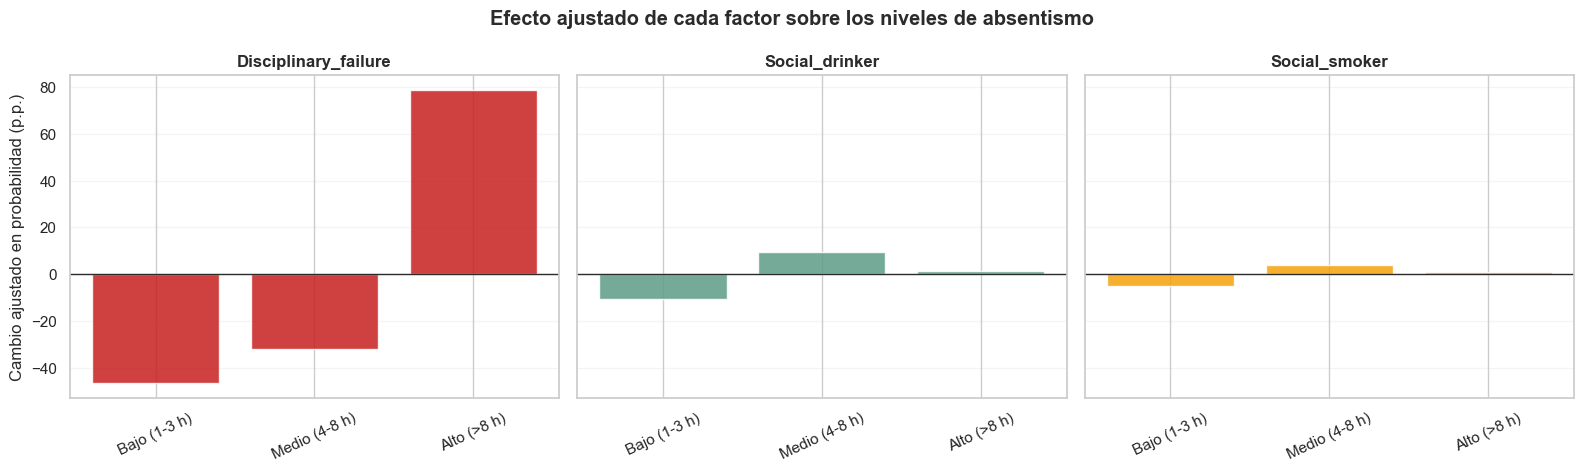

In [19]:
# Efectos ajustados: cambio medio en probabilidad al pasar cada factor
# de 0 a 1, manteniendo los otros factores como se observan en la muestra.
efectos_multinomial = []

for factor in factores:
    escenario_0 = X_multinomial.copy()
    escenario_1 = X_multinomial.copy()
    escenario_0[factor] = 0
    escenario_1[factor] = 1

    probabilidad_0 = modelo_multinomial.predict_proba(escenario_0).mean(axis=0)
    probabilidad_1 = modelo_multinomial.predict_proba(escenario_1).mean(axis=0)

    for posicion, nivel in enumerate(modelo_multinomial.classes_):
        efectos_multinomial.append({
            'factor': factor,
            'nivel_absentismo': nivel,
            'probabilidad_factor_0': probabilidad_0[posicion],
            'probabilidad_factor_1': probabilidad_1[posicion],
            'diferencia_puntos_porcentuales': (
                probabilidad_1[posicion] - probabilidad_0[posicion]
            ) * 100
        })

efectos_multinomial_df = pd.DataFrame(efectos_multinomial)
efectos_multinomial_df['nivel_absentismo'] = pd.Categorical(
    efectos_multinomial_df['nivel_absentismo'],
    categories=orden_niveles,
    ordered=True
)
efectos_multinomial_df = efectos_multinomial_df.sort_values(
    ['factor', 'nivel_absentismo']
)

display(efectos_multinomial_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

for ax, factor in zip(axes, factores):
    datos_factor = efectos_multinomial_df[
        efectos_multinomial_df['factor'] == factor
    ]
    colores = [
        '#C71F1F' if factor == 'Disciplinary_failure'
        else '#F5A20A' if factor == 'Social_smoker'
        else COLOR_VERDE_OSCURO
    ] * len(datos_factor)

    ax.bar(
        datos_factor['nivel_absentismo'].astype(str),
        datos_factor['diferencia_puntos_porcentuales'],
        color=colores,
        alpha=0.85
    )
    ax.axhline(0, color=COLOR_TEXTO, linewidth=1)
    ax.set_title(factor, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.2)
    ax.set_facecolor('none')

axes[0].set_ylabel('Cambio ajustado en probabilidad (p.p.)')
fig.suptitle(
    'Efecto ajustado de cada factor sobre los niveles de absentismo',
    fontweight='bold'
)
fig.patch.set_alpha(0)
plt.tight_layout()
plt.show()


**Lectura multinomial:** el modelo ajustado confirma que alcohol y tabaco apenas modifican la probabilidad estimada de pertenecer al nivel alto.
Los antecedentes disciplinarios concentran una gran variación hacia el nivel alto, incluso después de ajustar por los dos hábitos sociales.

La capacidad predictiva global es limitada y el resultado disciplinario depende de pocos casos concentrados. 
Por ello, el modelo se utiliza para explicar la asociación observada, no para clasificar empleados ni tomar decisiones individuales.

### 9.6 Regresión logística binaria de sensibilidad

Como comprobación adicional, se modela la pertenencia al nivel `Alto (>8 h)` frente a los niveles bajo y medio. Esta regresión simplifica el resultado y
permite evaluar si las conclusiones cambian al centrarse únicamente en el grupo de mayor impacto.

In [20]:
df_modelo_alto = df_niveles.copy()
df_modelo_alto['nivel_alto'] = (
    df_modelo_alto['nivel_absentismo'] == 'Alto (>8 h)'
).astype(int)

X_alto = df_modelo_alto[factores].astype(float)
y_alto = df_modelo_alto['nivel_alto']
evaluacion_logistica_alto = []

for C in valores_C:
    modelo_candidato = LogisticRegression(
        C=C,
        penalty='l2',
        solver='lbfgs',
        max_iter=5000
    )
    probabilidad_cv = cross_val_predict(
        modelo_candidato,
        X_alto,
        y_alto,
        cv=cv_modelos,
        method='predict_proba'
    )[:, 1]
    prediccion_cv = (probabilidad_cv >= 0.5).astype(int)

    evaluacion_logistica_alto.append({
        'C': C,
        'log_loss_cv': log_loss(y_alto, probabilidad_cv),
        'roc_auc_cv': roc_auc_score(y_alto, probabilidad_cv),
        'balanced_accuracy_cv': balanced_accuracy_score(
            y_alto,
            prediccion_cv
        ),
        'brier_score_cv': brier_score_loss(y_alto, probabilidad_cv)
    })

evaluacion_logistica_alto = pd.DataFrame(evaluacion_logistica_alto)
C_logistica_alto = evaluacion_logistica_alto.loc[
    evaluacion_logistica_alto['log_loss_cv'].idxmin(),
    'C'
]

modelo_logistica_alto = LogisticRegression(
    C=C_logistica_alto,
    penalty='l2',
    solver='lbfgs',
    max_iter=5000
).fit(X_alto, y_alto)

odds_ratio_regularizadas = pd.DataFrame({
    'factor': factores,
    'coeficiente_regularizado': modelo_logistica_alto.coef_[0],
    'odds_ratio_regularizada': np.exp(modelo_logistica_alto.coef_[0])
})

display(evaluacion_logistica_alto)
print('C seleccionado:', C_logistica_alto)
display(odds_ratio_regularizadas.round(3))


,C,log_loss_cv,roc_auc_cv,balanced_accuracy_cv,brier_score_cv
0,0.01,0.475506,0.605277,0.500000,0.149786
1,0.10,0.449515,0.599216,0.500000,0.139852
2,1.00,0.411421,0.578265,0.634639,0.121983
3,10.00,0.406646,0.572832,0.634639,0.119916
4,100.00,0.410866,0.572832,0.634639,0.119898


C seleccionado: 10.0


,factor,coeficiente_regularizado,odds_ratio_regularizada
0,Disciplinary_failure,4.299,73.611
1,Social_drinker,0.097,1.102
2,Social_smoker,0.091,1.096


**Lectura de sensibilidad:** la regresión binaria reproduce la misma conclusión sustantiva: los antecedentes disciplinarios son la principal señal asociada al nivel alto; alcohol y tabaco aportan poca capacidad explicativa.

Las métricas de validación cruzada muestran que los tres factores, por sí solos, no permiten predecir adecuadamente quién pertenecerá al nivel alto. Faltan variables laborales, temporales y sobre el motivo de ausencia.


## 10. Análisis complementario por frecuencia de registros

Además de las horas acumuladas, se analiza la recurrencia: cuántos registros con `Absenteeism_hours > 0` presenta cada empleado. Se excluyen las filas de cero horas, porque no representan ausencias y la mayoría corresponden a registros disciplinarios administrativos.

El dataset no contiene una fecha completa ni un identificador único de episodio. Por ello, esta medida se interpreta como **número de registros con ausencia**, no como número exacto de episodios independientes.


In [21]:
df_frecuencia = (
    df_rrhh
    .groupby('ID', as_index=False)
    .agg(
        registros_con_ausencia=(
            'Absenteeism_hours',
            lambda serie: (serie > 0).sum()
        ),
        horas_totales_absentismo=('Absenteeism_hours', 'sum'),
        Disciplinary_failure=('Disciplinary_failure', 'max'),
        Social_drinker=('Social_drinker', 'first'),
        Social_smoker=('Social_smoker', 'first')
    )
)

resultados_frecuencia = []
for factor in factores:
    grupo_0 = df_frecuencia.loc[
        df_frecuencia[factor] == 0,
        'registros_con_ausencia'
    ]
    grupo_1 = df_frecuencia.loc[
        df_frecuencia[factor] == 1,
        'registros_con_ausencia'
    ]
    estadistico, p_value = mannwhitneyu(
        grupo_0,
        grupo_1,
        alternative='two-sided'
    )
    resultados_frecuencia.append({
        'factor': factor,
        'n_grupo_0': len(grupo_0),
        'n_grupo_1': len(grupo_1),
        'mediana_registros_grupo_0': grupo_0.median(),
        'mediana_registros_grupo_1': grupo_1.median(),
        'media_registros_grupo_0': grupo_0.mean(),
        'media_registros_grupo_1': grupo_1.mean(),
        'p_value': p_value,
        'significativo_005': p_value < 0.05
    })

resultados_frecuencia_df = pd.DataFrame(resultados_frecuencia)
resultados_frecuencia_df

,factor,n_grupo_0,n_grupo_1,mediana_registros_grupo_0,mediana_registros_grupo_1,media_registros_grupo_0,media_registros_grupo_1,p_value,significativo_005
0,Disciplinary_failure,341,45,1.0,0.0,1.653959,10.555556,0.005226,True
1,Social_drinker,168,218,1.0,1.0,2.714286,2.674312,0.241861,False
2,Social_smoker,340,46,1.0,1.0,2.823529,1.717391,0.804597,False


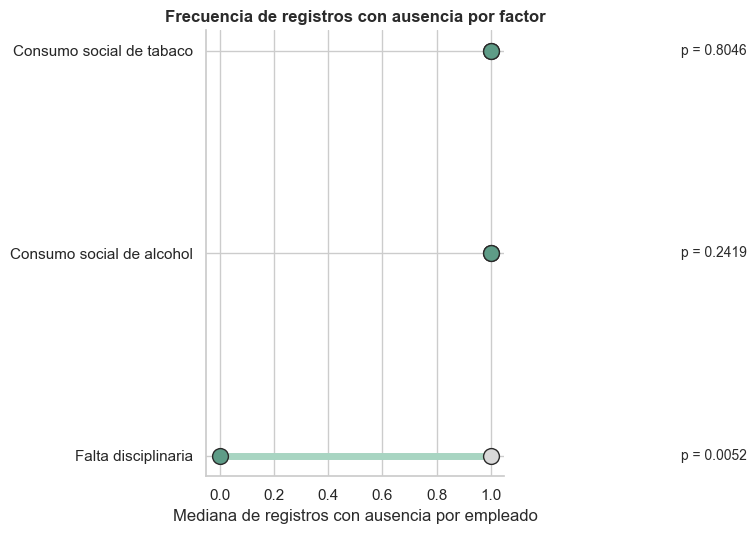

In [22]:
resumen_frecuencia = resultados_frecuencia_df.copy()
resumen_frecuencia['factor_nombre'] = resumen_frecuencia['factor'].map(nombres)

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_alpha(0)
ax.set_facecolor('none')

for posicion, fila in resumen_frecuencia.iterrows():
    mediana_0 = fila['mediana_registros_grupo_0']
    mediana_1 = fila['mediana_registros_grupo_1']
    ax.plot(
        [mediana_0, mediana_1],
        [posicion, posicion],
        color=COLOR_VERDE_CLARO,
        linewidth=5,
        solid_capstyle='round'
    )
    ax.scatter(mediana_0, posicion, s=130, color=COLOR_GRIS, edgecolor=COLOR_TEXTO, zorder=3)
    ax.scatter(mediana_1, posicion, s=130, color=COLOR_VERDE_OSCURO, edgecolor=COLOR_TEXTO, zorder=3)
    p_texto = 'p < 0.001' if fila['p_value'] < 0.001 else f"p = {fila['p_value']:.4f}"
    ax.text(
        max(mediana_0, mediana_1) + 0.7,
        posicion,
        p_texto,
        va='center',
        fontsize=10
    )

ax.set_yticks(range(len(resumen_frecuencia)))
ax.set_yticklabels(resumen_frecuencia['factor_nombre'])
ax.set_xlabel('Mediana de registros con ausencia por empleado')
ax.set_title('Frecuencia de registros con ausencia por factor', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('grafica6_frecuencia_registros.png', dpi=150, bbox_inches='tight')
plt.show()

**Lectura por frecuencia:** alcohol y tabaco no presentan diferencias estadísticamente significativas en la recurrencia. Los antecedentes disciplinarios sí presentan una diferencia estadística, aunque el grupo incluye numerosos empleados con cero registros de ausencia.

La frecuencia y las horas aportan perspectivas relacionadas pero distintas: una persona puede acumular muchas horas en pocas ausencias prolongadas o muchas ausencias de corta duración.


### 10.1 Síntesis visual de duración y frecuencia

Para cerrar la parte analítica, se presentan conjuntamente las dos medidas utilizadas: duración acumulada y frecuencia de registros con ausencia. Esta visualización no añade un test nuevo, sino que reúne en una misma lectura los resultados obtenidos anteriormente.


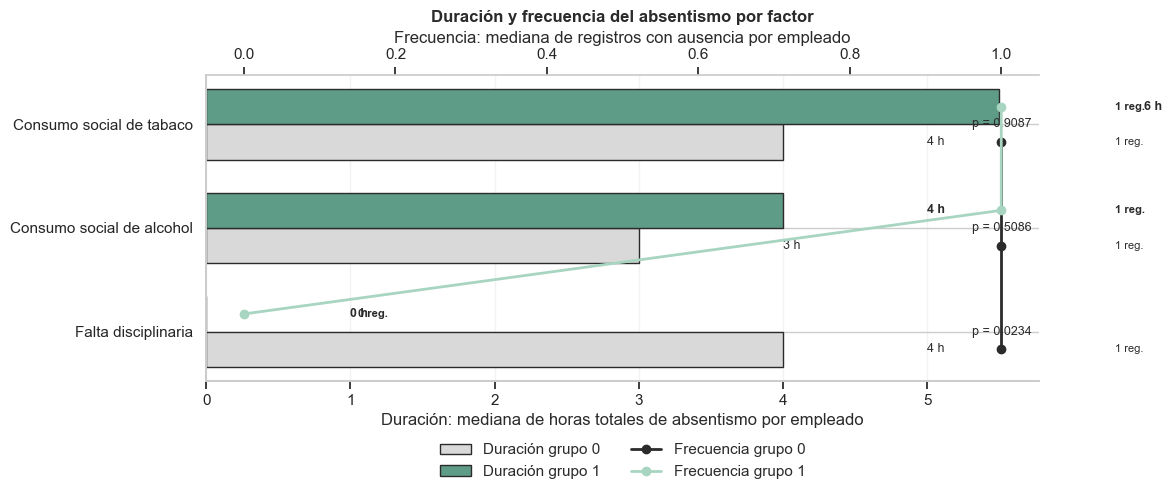

In [23]:
resumen_combinado = resultados_tests.copy()

resumen_combinado = resumen_combinado.merge(
    resultados_frecuencia_df[
        [
            'factor',
            'mediana_registros_grupo_0',
            'mediana_registros_grupo_1'
        ]
    ],
    on='factor',
    how='left'
)

resumen_combinado['factor_nombre'] = resumen_combinado['factor'].map(nombres)

# Orden sugerido: dejar los factores en el mismo orden que ya tenés
posiciones = np.arange(len(resumen_combinado))
alto_barra = 0.34

fig, ax_duracion = plt.subplots(figsize=(12, 5.8))
fig.patch.set_alpha(0)
ax_duracion.set_facecolor('none')

# Segundo eje X para frecuencia
ax_frecuencia = ax_duracion.twiny()
ax_frecuencia.set_facecolor('none')


# ------------------------------------------------------------
# BARRAS: DURACIÓN
# ------------------------------------------------------------

ax_duracion.barh(
    posiciones - alto_barra / 2,
    resumen_combinado['mediana_grupo_0'],
    height=alto_barra,
    color=COLOR_GRIS,
    edgecolor=COLOR_TEXTO,
    label='Duración grupo 0'
)

ax_duracion.barh(
    posiciones + alto_barra / 2,
    resumen_combinado['mediana_grupo_1'],
    height=alto_barra,
    color=COLOR_VERDE_OSCURO,
    edgecolor=COLOR_TEXTO,
    label='Duración grupo 1'
)


# ------------------------------------------------------------
# LÍNEA / PUNTOS: FRECUENCIA
# ------------------------------------------------------------

ax_frecuencia.plot(
    resumen_combinado['mediana_registros_grupo_0'],
    posiciones - alto_barra / 2,
    marker='o',
    linewidth=2,
    color=COLOR_TEXTO,
    label='Frecuencia grupo 0',
    zorder=4
)

ax_frecuencia.plot(
    resumen_combinado['mediana_registros_grupo_1'],
    posiciones + alto_barra / 2,
    marker='o',
    linewidth=2,
    color=COLOR_VERDE_CLARO,
    label='Frecuencia grupo 1',
    zorder=4
)


# ------------------------------------------------------------
# ETIQUETAS DE VALORES Y P-VALUES
# ------------------------------------------------------------

for posicion, fila in resumen_combinado.iterrows():

    # Etiquetas duración
    ax_duracion.text(
        fila['mediana_grupo_0'] + 1,
        posicion - alto_barra / 2,
        f"{fila['mediana_grupo_0']:.0f} h",
        va='center',
        fontsize=9
    )

    ax_duracion.text(
        fila['mediana_grupo_1'] + 1,
        posicion + alto_barra / 2,
        f"{fila['mediana_grupo_1']:.0f} h",
        va='center',
        fontsize=9,
        fontweight='bold'
    )

    # Etiquetas frecuencia
    ax_frecuencia.text(
        fila['mediana_registros_grupo_0'] + 0.15,
        posicion - alto_barra / 2,
        f"{fila['mediana_registros_grupo_0']:.0f} reg.",
        va='center',
        fontsize=8
    )

    ax_frecuencia.text(
        fila['mediana_registros_grupo_1'] + 0.15,
        posicion + alto_barra / 2,
        f"{fila['mediana_registros_grupo_1']:.0f} reg.",
        va='center',
        fontsize=8,
        fontweight='bold'
    )

    # P-value del test de duración
    p_texto = 'p < 0.001' if fila['p_value'] < 0.001 else f"p = {fila['p_value']:.4f}"

    ax_duracion.text(
        ax_duracion.get_xlim()[1] * 0.92,
        posicion,
        p_texto,
        va='center',
        fontsize=9
    )


# ------------------------------------------------------------
# FORMATO GENERAL
# ------------------------------------------------------------

ax_duracion.set_yticks(posiciones)
ax_duracion.set_yticklabels(resumen_combinado['factor_nombre'])

ax_duracion.set_xlabel('Duración: mediana de horas totales de absentismo por empleado')
ax_frecuencia.set_xlabel('Frecuencia: mediana de registros con ausencia por empleado')

ax_duracion.set_title(
    'Duración y frecuencia del absentismo por factor',
    fontweight='bold'
)

ax_duracion.spines[['top', 'right']].set_visible(False)
ax_frecuencia.spines[['right']].set_visible(False)

ax_duracion.grid(axis='x', alpha=0.25)
ax_frecuencia.grid(False)

# Unificar leyendas
handles_1, labels_1 = ax_duracion.get_legend_handles_labels()
handles_2, labels_2 = ax_frecuencia.get_legend_handles_labels()

ax_duracion.legend(
    handles_1 + handles_2,
    labels_1 + labels_2,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.16),
    ncol=2
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('grafica_duracion_barras_frecuencia_linea.png', dpi=150, bbox_inches='tight')
plt.show()

**Lectura conjunta:** alcohol y tabaco mantienen diferencias pequeñas y no significativas tanto en duración como en frecuencia. Los antecedentes disciplinarios son el único factor que conserva una asociación estadística a través de las distintas comprobaciones, aunque su interpretación continúa condicionada por la ausencia de información temporal.


## 11. Síntesis de las validaciones realizadas

La conclusión no depende de un único gráfico ni de un único test. Primero se verificó la unidad de análisis para evitar contar varias veces al mismo empleado y se comprobó el comportamiento particular de `Disciplinary_failure` antes de realizar contrastes. Después se revisaron tamaños de grupo, distribución, mediana, dispersión y valores extremos para seleccionar Mann-Whitney U como prueba principal.

La relación se estudió desde tres perspectivas complementarias: duración total del absentismo, frecuencia de registros con ausencia y pertenencia a los niveles bajo, medio y alto. Chi-cuadrado y Fisher permitieron contrastar las variables categorizadas. Finalmente, la regresión multinomial regularizada ajustó simultáneamente los tres factores y la regresión binaria comprobó específicamente la pertenencia al nivel alto.

Todas las comprobaciones conducen a la misma conclusión general: alcohol y tabaco no muestran una relación estadísticamente significativa con el absentismo en la muestra ampliada, mientras que los antecedentes disciplinarios constituyen la señal más asociada al nivel alto. La coincidencia entre métodos aporta solidez a la conclusión, pero no resuelve la dirección temporal de esa relación.


## 12. Respuesta a la pregunta de negocio

- **Consumo social de alcohol:** no presenta una relación estadísticamente significativa con la duración, la frecuencia ni los niveles de absentismo. El efecto ajustado sobre la probabilidad de pertenecer al nivel alto es reducido.
- **Consumo social de tabaco:** tampoco presenta una relación estadísticamente significativa con las distintas medidas de absentismo. La regresión confirma que aporta poca capacidad explicativa una vez considerado junto con los demás factores.
- **Antecedentes disciplinarios:** constituyen la asociación más clara con el nivel alto de absentismo. Esta señal se mantiene en los contrastes por duración y frecuencia, en el análisis por niveles y en ambas regresiones.

No puede afirmarse si los antecedentes disciplinarios preceden a las ausencias o si son consecuencia de ausencias reiteradas, porque el dataset no incluye la fecha del antecedente. Por ello, la conclusión describe una asociación consistente, no una relación causal ni una herramienta suficiente para predecir el comportamiento individual.


## 13. Propuestas vinculadas a los resultados

- **Alcohol y tabaco:** no utilizarlos como criterios de segmentación o decisión individual. Las acciones relacionadas deben limitarse a iniciativas generales y voluntarias de salud y bienestar.
- **Antecedentes disciplinarios:** registrar la fecha, el motivo y el tipo de antecedente para determinar si ocurre antes o después de las ausencias. Mientras no exista esa información, debe utilizarse únicamente como señal para una revisión contextual y nunca como criterio automático.
- **Seguimiento del absentismo:** incorporar fecha completa, identificador del episodio, puesto, turno, modalidad contractual y motivo de ausencia para distinguir mejor duración, recurrencia y contexto.
- **Modelización futura:** repetir los modelos con nuevas entregas y revisar su estabilidad, calibración y capacidad predictiva antes de considerar cualquier aplicación operativa.

**Lectura para dirección:** la señal disciplinaria merece investigación interna, pero los tres factores analizados no son suficientes para clasificar empleados ni justificar decisiones individuales.


## 14. Justificación técnica: por qué la regresión no fue el punto de partida

No se recurrió inicialmente a una regresión porque la pregunta de negocio podía responderse primero mediante comparaciones directas, transparentes y fáciles de interpretar. Antes de construir un modelo era necesario confirmar la unidad de análisis, comprender la distribución de las horas, comprobar los tamaños de los grupos y detectar la relación estructural entre las filas disciplinarias y las cero horas.

Empezar directamente por una regresión habría ocultado varios problemas importantes. En particular, solo al estudiar las tablas y los niveles se observa que los antecedentes disciplinarios presentan una separación casi perfecta: no aparecen en el nivel bajo y se concentran principalmente en el alto. Una regresión multinomial convencional no converge correctamente en estas condiciones y habría generado coeficientes inestables si no se hubiera detectado antes este patrón.

La regresión se incorpora al final porque aporta una validación adicional: permite estudiar los tres factores simultáneamente y comprobar si la conclusión se mantiene después del ajuste. No sustituye a los análisis previos ni aporta causalidad. En este caso confirma una conclusión que ya era visible con métodos más sencillos, pero también demuestra que la capacidad predictiva de los tres factores es limitada.


## 15. Limitaciones

- El dataset no contiene la fecha completa ni un identificador único de cada episodio de ausencia, por lo que la frecuencia representa registros con ausencia y no necesariamente episodios independientes.
- No se conoce la fecha de los antecedentes disciplinarios. Por ello, no puede determinarse si preceden al absentismo o si aparecen como consecuencia de ausencias reiteradas.
- Los tres factores analizados no incluyen otras variables laborales relevantes, como puesto, turno, modalidad contractual o contexto organizativo.
- La concentración de antecedentes disciplinarios en el nivel alto provoca separación casi perfecta y obliga a utilizar regresión regularizada.
- Los modelos presentan una capacidad predictiva limitada y no deben emplearse para clasificar empleados ni tomar decisiones individuales.


> 🎤 **NOTAS DEL ORADOR**
>
> La conclusión se repite al observar duración, frecuencia, niveles y modelos ajustados: alcohol y tabaco no muestran una relación clara; los antecedentes disciplinarios sí se concentran en el absentismo alto. La regresión se utiliza como confirmación avanzada, no porque los análisis anteriores fueran insuficientes. El punto pendiente es conocer qué ocurrió primero y añadir variables laborales que expliquen mejor el absentismo.


### Cierre

El análisis responde de forma consistente a la pregunta de negocio después de aplicar verificaciones descriptivas, contrastes estadísticos y modelos ajustados. La muestra ampliada no respalda una relación clara entre consumo social de alcohol o tabaco y absentismo. Los antecedentes disciplinarios constituyen la asociación más fuerte con el nivel alto, pero su temporalidad y significado operativo deben validarse antes de traducir el resultado en decisiones.

Las regresiones confirman la dirección general de los análisis previos y muestran, al mismo tiempo, que los tres factores poseen una capacidad predictiva limitada. La principal conclusión no cambia al aumentar la complejidad del método; lo que cambia es el grado de validación con el que puede sostenerse.
